In [ ]:
# ===============================
#        ADNI DATASET
# ===============================

#load dataset
import pandas as pd
df=pd.read_csv('/content/UPENN_PLASMA_FUJIREBIO_QUANTERIX_18Feb2026.csv')
df.isnull().sum()

,0
PHASE,0
PTID,0
RID,0
VISCODE,0
VISCODE2,0
EXAMDATE,0
Primary,0
Additive,0
pT217_F,0
AB42_F,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2178 entries, 0 to 2177
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PHASE         2178 non-null   object 
 1   PTID          2178 non-null   object 
 2   RID           2178 non-null   int64  
 3   VISCODE       2178 non-null   object 
 4   VISCODE2      2178 non-null   object 
 5   EXAMDATE      2178 non-null   object 
 6   Primary       2178 non-null   object 
 7   Additive      2178 non-null   object 
 8   pT217_F       2178 non-null   float64
 9   AB42_F        2178 non-null   float64
 10  AB40_F        2178 non-null   float64
 11  AB42_AB40_F   2178 non-null   float64
 12  pT217_AB42_F  2178 non-null   float64
 13  NfL_Q         2178 non-null   float64
 14  GFAP_Q        2178 non-null   float64
 15  NfL_F         2178 non-null   float64
 16  GFAP_F        2178 non-null   float64
 17  Comment       450 non-null    object 
 18  update_stamp  2178 non-null 

In [ ]:
cols_to_remove = ['PHASE','PTID','EXAMDATE','Primary','Additive','Comment','update_stamp']
df = df.drop(columns=cols_to_remove)
df.head()

,RID,VISCODE,VISCODE2,pT217_F,AB42_F,AB40_F,AB42_AB40_F,pT217_AB42_F,NfL_Q,GFAP_Q,NfL_F,GFAP_F
0,2,bl,bl,0.199,27.92,324.12,0.086100,0.007130,14.9,94.6,-4.0,-4.0
1,8,bl,bl,0.152,27.90,296.53,0.094088,0.005448,26.6,141.1,-4.0,-4.0
2,8,v41,m120,0.235,7.24,70.00,0.103429,0.032459,55.8,289.1,-4.0,-4.0
3,10,bl,bl,0.472,24.44,332.15,0.073581,0.019313,26.5,194.3,-4.0,-4.0
4,10,m24,m24,0.586,19.61,288.14,0.068057,0.029883,30.2,221.3,-4.0,-4.0


In [ ]:
import pandas as pd
df_cdr = pd.read_csv('/content/CDR_18Feb2026.csv')
df_adas = pd.read_csv('/content/ADAS_18Feb2026.csv')
df_mmse = pd.read_csv('/content/MMSE_18Feb2026.csv')
df_dx = pd.read_csv('/content/diagnosis.csv')



df_cdr.head()
df_adas.head()
df_mmse.head()
df_dx.head()


,PHASE,PTID,RID,VISCODE,VISCODE2,EXAMDATE,DIAGNOSIS,DXNORM,DXNODEP,DXMCI,...,DXODES,DXCONFID,ID,SITEID,USERDATE,USERDATE2,DD_CRF_VERSION_LABEL,LANGUAGE_CODE,HAS_QC_ERROR,update_stamp
0,ADNI1,011_S_0002,2,bl,bl,2005-09-29,1.0,1.0,-4.0,-4.0,...,-4.0,4.0,2,107,2005-10-01,NaN,NaN,NaN,NaN,2005-10-01 00:00:00
1,ADNI1,011_S_0003,3,bl,bl,2005-09-30,3.0,-4.0,-4.0,-4.0,...,-4.0,3.0,4,107,2005-10-01,NaN,NaN,NaN,NaN,2005-10-01 00:00:00
2,ADNI1,011_S_0005,5,bl,bl,2005-09-30,1.0,1.0,-4.0,-4.0,...,-4.0,4.0,6,107,2005-10-01,NaN,NaN,NaN,NaN,2005-10-01 00:00:00
3,ADNI1,011_S_0008,8,bl,bl,2005-09-30,1.0,1.0,-4.0,-4.0,...,-4.0,3.0,8,107,2005-10-01,NaN,NaN,NaN,NaN,2005-10-01 00:00:00
4,ADNI1,022_S_0007,7,bl,bl,2005-10-06,3.0,-4.0,-4.0,-4.0,...,-4.0,4.0,10,10,2005-10-06,NaN,NaN,NaN,NaN,2005-10-06 00:00:00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2178 entries, 0 to 2177
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   RID           2178 non-null   int64  
 1   VISCODE       2178 non-null   object 
 2   VISCODE2      2178 non-null   object 
 3   pT217_F       2178 non-null   float64
 4   AB42_F        2178 non-null   float64
 5   AB40_F        2178 non-null   float64
 6   AB42_AB40_F   2178 non-null   float64
 7   pT217_AB42_F  2178 non-null   float64
 8   NfL_Q         2178 non-null   float64
 9   GFAP_Q        2178 non-null   float64
 10  NfL_F         2178 non-null   float64
 11  GFAP_F        2178 non-null   float64
dtypes: float64(9), int64(1), object(2)
memory usage: 204.3+ KB


In [ ]:
# 1. Define the keys to join on
join_keys = ['RID', 'VISCODE', 'VISCODE2']

# 2. Select only the necessary columns from each table
# Table 1: CDR (Keeping Sum of Boxes)
cdr_subset = df_cdr[join_keys + ['CDRSB']]

# Table 2: ADAS (Keeping TOTAL13)
adas_subset = df_adas[join_keys + ['TOTAL13']]

# Table 3: MMSE (Keeping MMSCORE)
mmse_subset = df_mmse[join_keys + ['MMSCORE']]

# Table 4: Diagnosis
dx_subset = df_dx[join_keys + ['DIAGNOSIS']]

# 3. Perform the sequential merge
# Start with your main 'df' (ensure it has RID, VISCODE, VISCODE2 columns)
df_merged = df.merge(cdr_subset, on=join_keys, how='left')
df_merged = df_merged.merge(adas_subset, on=join_keys, how='left')
df_merged = df_merged.merge(mmse_subset, on=join_keys, how='left')
df_merged = df_merged.merge(dx_subset, on=join_keys, how='left')



print(f"Merge Complete. Final columns: {df_merged.columns.tolist()}")

Merge Complete. Final columns: ['RID', 'VISCODE', 'VISCODE2', 'pT217_F', 'AB42_F', 'AB40_F', 'AB42_AB40_F', 'pT217_AB42_F', 'NfL_Q', 'GFAP_Q', 'NfL_F', 'GFAP_F', 'CDRSB', 'TOTAL13', 'MMSCORE', 'DIAGNOSIS']


In [ ]:
df_merged.isnull().sum()
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2178 entries, 0 to 2177
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   RID           2178 non-null   int64  
 1   VISCODE       2178 non-null   object 
 2   VISCODE2      2178 non-null   object 
 3   pT217_F       2178 non-null   float64
 4   AB42_F        2178 non-null   float64
 5   AB40_F        2178 non-null   float64
 6   AB42_AB40_F   2178 non-null   float64
 7   pT217_AB42_F  2178 non-null   float64
 8   NfL_Q         2178 non-null   float64
 9   GFAP_Q        2178 non-null   float64
 10  NfL_F         2178 non-null   float64
 11  GFAP_F        2178 non-null   float64
 12  CDRSB         934 non-null    float64
 13  TOTAL13       2070 non-null   float64
 14  MMSCORE       948 non-null    float64
 15  DIAGNOSIS     2162 non-null   float64
dtypes: float64(13), int64(1), object(2)
memory usage: 272.4+ KB


In [ ]:

# Drop rows where the target diagnosis is missing
df_merged = df_merged.dropna(subset=['DIAGNOSIS'])
df_merged.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2162 entries, 0 to 2176
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   RID           2162 non-null   int64  
 1   VISCODE       2162 non-null   object 
 2   VISCODE2      2162 non-null   object 
 3   pT217_F       2162 non-null   float64
 4   AB42_F        2162 non-null   float64
 5   AB40_F        2162 non-null   float64
 6   AB42_AB40_F   2162 non-null   float64
 7   pT217_AB42_F  2162 non-null   float64
 8   NfL_Q         2162 non-null   float64
 9   GFAP_Q        2162 non-null   float64
 10  NfL_F         2162 non-null   float64
 11  GFAP_F        2162 non-null   float64
 12  CDRSB         930 non-null    float64
 13  TOTAL13       2060 non-null   float64
 14  MMSCORE       942 non-null    float64
 15  DIAGNOSIS     2162 non-null   float64
dtypes: float64(13), int64(1), object(2)
memory usage: 287.1+ KB


In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

clinical_cols = ['CDRSB', 'MMSCORE', 'TOTAL13']

# Impute separately for each diagnosis to avoid "bleeding" patterns across groups
for dx in df_merged['DIAGNOSIS'].unique():
    mask = df_merged['DIAGNOSIS'] == dx

    # Initialize MICE Imputer
    imputer = IterativeImputer(max_iter=20, random_state=42)

    # Apply to clinical columns
    df_merged.loc[mask, clinical_cols] = imputer.fit_transform(df_merged.loc[mask, clinical_cols])
df_merged.isnull().sum()

,0
RID,0
VISCODE,0
VISCODE2,0
pT217_F,0
AB42_F,0
AB40_F,0
AB42_AB40_F,0
pT217_AB42_F,0
NfL_Q,0
GFAP_Q,0


In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2162 entries, 0 to 2176
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   RID           2162 non-null   int64  
 1   VISCODE       2162 non-null   object 
 2   VISCODE2      2162 non-null   object 
 3   pT217_F       2162 non-null   float64
 4   AB42_F        2162 non-null   float64
 5   AB40_F        2162 non-null   float64
 6   AB42_AB40_F   2162 non-null   float64
 7   pT217_AB42_F  2162 non-null   float64
 8   NfL_Q         2162 non-null   float64
 9   GFAP_Q        2162 non-null   float64
 10  NfL_F         2162 non-null   float64
 11  GFAP_F        2162 non-null   float64
 12  CDRSB         2162 non-null   float64
 13  TOTAL13       2162 non-null   float64
 14  MMSCORE       2162 non-null   float64
 15  DIAGNOSIS     2162 non-null   float64
dtypes: float64(13), int64(1), object(2)
memory usage: 287.1+ KB


In [ ]:
#ratio engineering
# ===============================
# 2. SAFE BIOMARKER RATIOS
# ===============================
eps = 1e-6
df=df_merged
df['pT217_AB42'] = df['pT217_F'] / (df['AB42_F'] + eps)
df['pT217_AB42_AB40'] = df['pT217_F'] / (df['AB42_AB40_F'] + eps)   #so to prevent division by 0 and explosion if the denominator is near 0
df['GFAP_AB42'] = df['GFAP_Q'] / (df['AB42_F'] + eps)
df['NfL_AB42'] = df['NfL_Q'] / (df['AB42_F'] + eps)

# Clip extreme ratio outliers (99th percentile)
ratio_cols = ['pT217_AB42', 'pT217_AB42_AB40', 'GFAP_AB42', 'NfL_AB42'] #to handle extreme values in the ratios
for col in ratio_cols:
    df[col] = df[col].clip(upper=df[col].quantile(0.99))
df_merged.isnull().sum()

,0
RID,0
VISCODE,0
VISCODE2,0
pT217_F,0
AB42_F,0
AB40_F,0
AB42_AB40_F,0
pT217_AB42_F,0
NfL_Q,0
GFAP_Q,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2162 entries, 0 to 2176
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RID              2162 non-null   int64  
 1   VISCODE          2162 non-null   object 
 2   VISCODE2         2162 non-null   object 
 3   pT217_F          2162 non-null   float64
 4   AB42_F           2162 non-null   float64
 5   AB40_F           2162 non-null   float64
 6   AB42_AB40_F      2162 non-null   float64
 7   pT217_AB42_F     2162 non-null   float64
 8   NfL_Q            2162 non-null   float64
 9   GFAP_Q           2162 non-null   float64
 10  NfL_F            2162 non-null   float64
 11  GFAP_F           2162 non-null   float64
 12  CDRSB            2162 non-null   float64
 13  TOTAL13          2162 non-null   float64
 14  MMSCORE          2162 non-null   float64
 15  DIAGNOSIS        2162 non-null   float64
 16  pT217_AB42       2162 non-null   float64
 17  pT217_AB42_AB40  21

Class Counts:
DIAGNOSIS
1.0    1093
2.0     700
3.0     369
Name: count, dtype: int64

Percentage Distribution:
DIAGNOSIS
1.0    50.555042
2.0    32.377428
3.0    17.067530
Name: proportion, dtype: float64


/tmp/ipython-input-3590226259.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='DIAGNOSIS', data=df, palette='viridis', order=df['DIAGNOSIS'].value_counts().index)


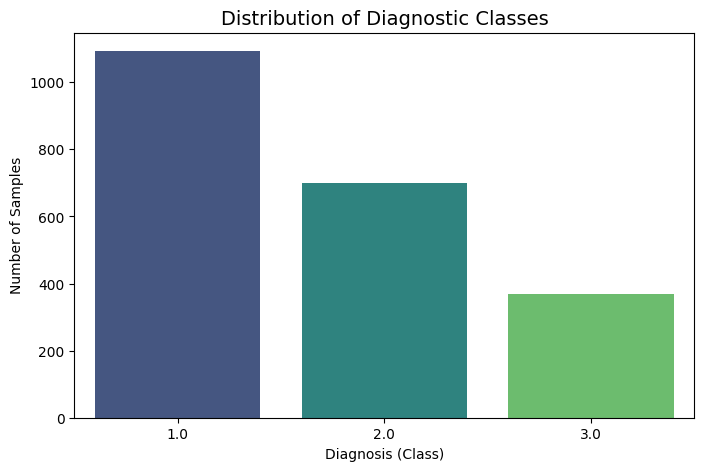

In [ ]:
#handling class imbalance
# Check raw counts for each class
print("Class Counts:")
counts = df['DIAGNOSIS'].value_counts()
print(counts)

# Check the percentage distribution
print("\nPercentage Distribution:")
print(df['DIAGNOSIS'].value_counts(normalize=True) * 100)
import seaborn as sns                                                   #1-cn 2-MCI 3- AD
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(x='DIAGNOSIS', data=df, palette='viridis', order=df['DIAGNOSIS'].value_counts().index)
plt.title('Distribution of Diagnostic Classes', fontsize=14)
plt.ylabel('Number of Samples')
plt.xlabel('Diagnosis (Class)')
plt.show()

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00



--- 5-Fold GroupCV Performance ---
Accuracy           : 0.9348
Balanced Accuracy  : 0.9296
F1 Macro           : 0.9298


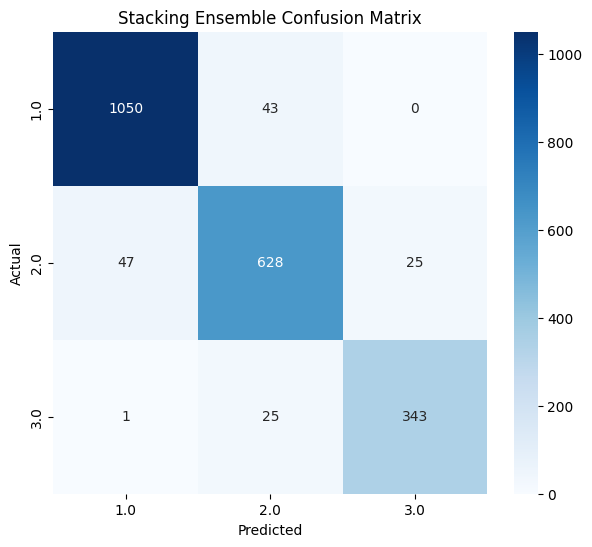


--- Classification Report ---
              precision    recall  f1-score   support

         1.0       0.96      0.96      0.96      1093
         2.0       0.90      0.90      0.90       700
         3.0       0.93      0.93      0.93       369

    accuracy                           0.93      2162
   macro avg       0.93      0.93      0.93      2162
weighted avg       0.93      0.93      0.93      2162


--- Sensitivity & Specificity ---

Class: 1.0
Sensitivity (Recall): 0.9607
Specificity         : 0.9551

Class: 2.0
Sensitivity (Recall): 0.8971
Specificity         : 0.9535

Class: 3.0
Sensitivity (Recall): 0.9295
Specificity         : 0.9861


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ===============================
# 1. FEATURES
# ===============================
features = [
    'pT217_F', 'AB42_F', 'AB40_F', 'AB42_AB40_F',
    'NfL_Q', 'GFAP_Q','NfL_F', 'GFAP_F',
    'CDRSB', 'MMSCORE', 'TOTAL13',
    'pT217_AB42', 'pT217_AB42_AB40', 'GFAP_AB42', 'NfL_AB42'
]

X = df[features]
y = df['DIAGNOSIS']
groups = df['RID']

# ===============================
# 2. LABEL ENCODING
# ===============================
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ===============================
# 3. LIGHTER BASE MODELS (FASTER)
# ===============================

rf = RandomForestClassifier(
    n_estimators=120,
    n_jobs=-1,
    random_state=42
)

xgb = XGBClassifier(
    n_estimators=120,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=42
)

cat = CatBoostClassifier(
    iterations=200,
    depth=4,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)

# ===============================
# 4. STACKING MODEL
# ===============================

stack_model = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('cat', cat)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    n_jobs=-1
)

pipeline = ImbPipeline(steps=[
    ('smote_tomek', SMOTETomek(random_state=42)),
    ('stacking', stack_model)
])

# ===============================
# 5. SINGLE GROUP-KFOLD LOOP
# ===============================

gkf = GroupKFold(n_splits=5)

all_true = []
all_pred = []

acc_scores = []
bal_acc_scores = []
f1_scores = []

for train_idx, test_idx in gkf.split(X, y_encoded, groups):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    # Store predictions
    all_true.extend(y_test)
    all_pred.extend(preds)

    # Fold metrics
    acc_scores.append(accuracy_score(y_test, preds))
    bal_acc_scores.append(balanced_accuracy_score(y_test, preds))
    f1_scores.append(f1_score(y_test, preds, average='macro'))

# ===============================
# 6. CROSS-VALIDATED METRICS
# ===============================

print("\n--- 5-Fold GroupCV Performance ---")
print(f"Accuracy           : {np.mean(acc_scores):.4f}")
print(f"Balanced Accuracy  : {np.mean(bal_acc_scores):.4f}")
print(f"F1 Macro           : {np.mean(f1_scores):.4f}")

# ===============================
# 7. CONFUSION MATRIX
# ===============================

cm = confusion_matrix(all_true, all_pred)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stacking Ensemble Confusion Matrix")
plt.show()

# ===============================
# 8. CLASSIFICATION REPORT
# ===============================

print("\n--- Classification Report ---")
print(classification_report(
    le.inverse_transform(all_true),
    le.inverse_transform(all_pred)
))

# ===============================
# 9. SENSITIVITY & SPECIFICITY
# ===============================

print("\n--- Sensitivity & Specificity ---")

n_classes = cm.shape[0]

for i in range(n_classes):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)

    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)

    print(f"\nClass: {le.classes_[i]}")
    print(f"Sensitivity (Recall): {sensitivity:.4f}")
    print(f"Specificity         : {specificity:.4f}")
